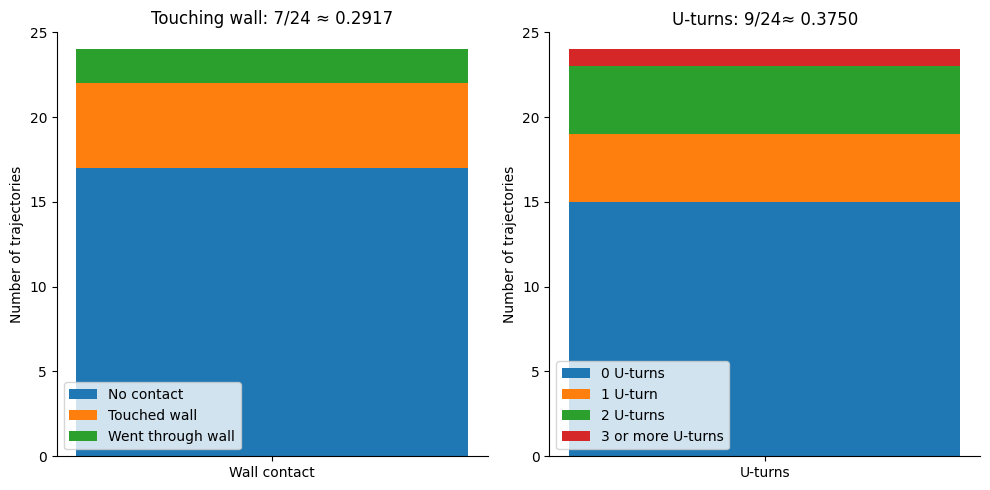

In [ ]:
import matplotlib.pyplot as plt

total = 24

# ---- Wall-touching stats ----
touch_total = 7          # 7/24 touched a wall
through_wall = 2         # of those 7, 2 went through a wall
touch_no_through = touch_total - through_wall
no_touch = total - touch_total
touch_fraction = touch_total / total

# ---- U-turn stats ----
paths_with_uturn = 9     # 9/24 did at least one U-turn
paths_two_uturns = 4     # 4 of those did two U-turns
paths_three_uturns = 1
paths_one_uturn = paths_with_uturn - paths_two_uturns - paths_three_uturns
paths_zero_uturn = total - paths_with_uturn
u_turn_fraction = paths_with_uturn / total

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: touching wall
ax = axes[0]
ax.bar("Wall contact", no_touch, label="No contact")
ax.bar("Wall contact", touch_no_through, bottom=no_touch, label="Touched wall")
ax.bar("Wall contact", through_wall,
       bottom=no_touch + touch_no_through,
       label="Went through wall")

ax.set_ylabel("Number of trajectories")
ax.set_ylim(0, total + 1)
ax.set_title(f"Touching wall: {touch_total}/{total} ≈ {touch_fraction:.4f}")
ax.legend()

# Right: U-turns
ax = axes[1]
bottom = 0
ax.bar("U-turns", paths_zero_uturn, label="0 U-turns")
bottom += paths_zero_uturn
ax.bar("U-turns", paths_one_uturn, bottom=bottom, label="1 U-turn")
bottom += paths_one_uturn
ax.bar("U-turns", paths_two_uturns, bottom=bottom, label="2 U-turns")
bottom += paths_two_uturns
ax.bar("U-turns", paths_three_uturns, bottom=bottom, label="3 or more U-turns")

ax.set_ylabel("Number of trajectories")
ax.set_ylim(0, total + 1)
ax.set_title(f"U-turns: {paths_with_uturn}/{total}≈ {u_turn_fraction:.4f}")
ax.legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


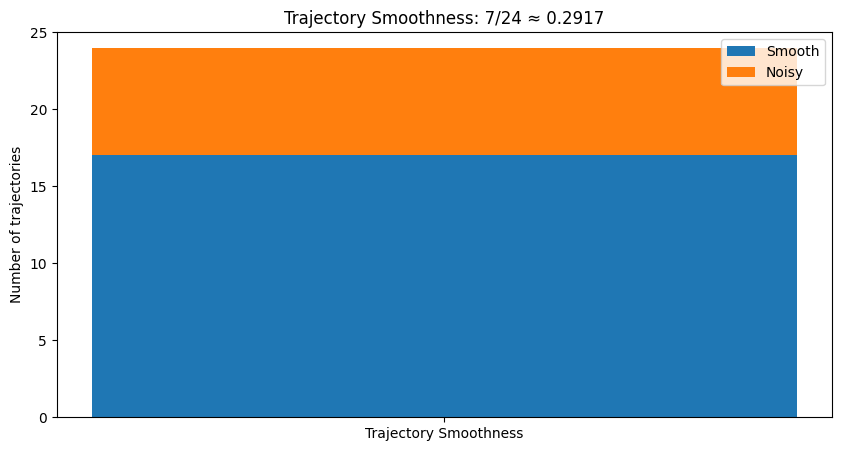

In [11]:
import matplotlib.pyplot as plt

total = 24

# Traj Smoothness Stats
touch_total = 7          # 7/24 touched a wall (any kind)
no_touch = total - touch_total
touch_fraction = touch_total / total

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 5))

# Single stacked bar: no contact + touched
ax.bar("Trajectory Smoothness", no_touch, label="Smooth")
ax.bar("Trajectory Smoothness", touch_total, bottom=no_touch, label="Noisy")

ax.set_ylabel("Number of trajectories")
ax.set_ylim(0, total + 1)
ax.set_title(f"Trajectory Smoothness: {touch_total}/{total} ≈ {touch_fraction:.4f}")
ax.legend()

plt.show()


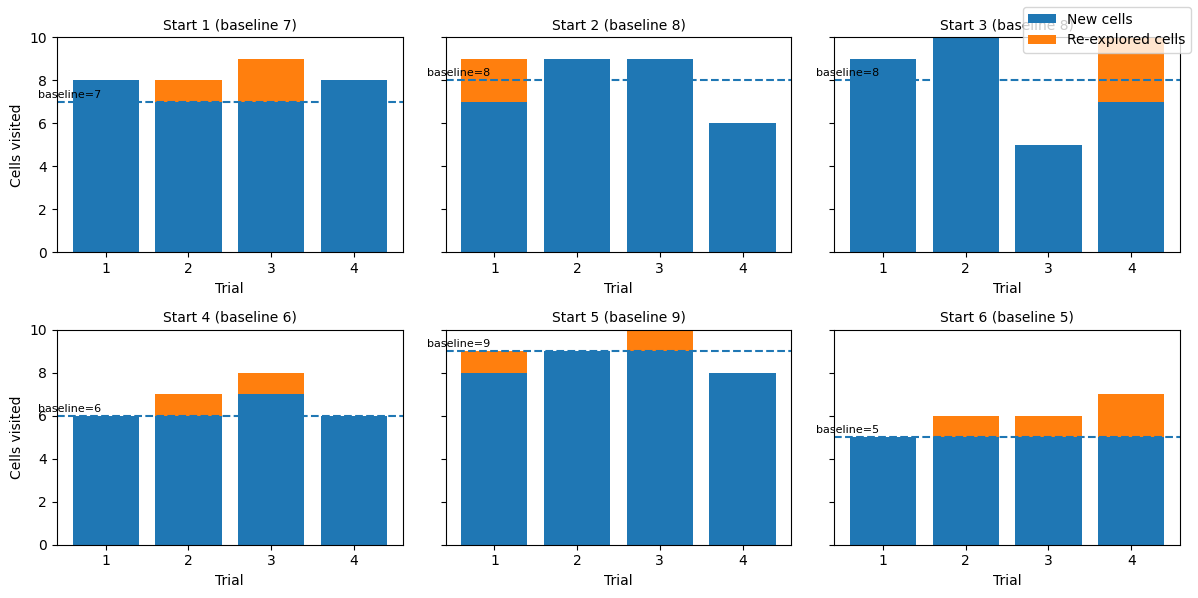

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- DATA --------------------------------------------------------
# Baseline reachable cells for each start
baselines = [7, 8, 8, 6, 9, 5]

# Total cells visited in each of 4 trials
visited = [
    [8, 8, 9, 8],    # Start 1
    [9, 9, 9, 6],    # Start 2
    [9, 10, 5, 10],  # Start 3
    [6, 7, 8, 6],    # Start 4
    [9, 9, 10, 8],   # Start 5
    [5, 6, 6, 7],    # Start 6
]

# Of those, how many were re-explored (revisited) cells
reexplored = [
    [0, 1, 2, 0],    # Start 1
    [2, 0, 0, 0],    # Start 2
    [0, 0, 0, 3],    # Start 3
    [0, 1, 1, 0],    # Start 4
    [1, 0, 1, 0],    # Start 5
    [0, 1, 1, 2],    # Start 6
]

# New (first-time) cells = total visited − re-explored
new_cells = [
    (np.array(v) - np.array(r)).tolist()
    for v, r in zip(visited, reexplored)
]

start_labels = [
    "Start 1 (baseline 7)",
    "Start 2 (baseline 8)",
    "Start 3 (baseline 8)",
    "Start 4 (baseline 6)",
    "Start 5 (baseline 9)",
    "Start 6 (baseline 5)",
]

trials = np.arange(1, 5)  # Trial indices 1..4

# --- PLOT --------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    v = np.array(visited[i])
    r = np.array(reexplored[i])
    n = np.array(new_cells[i])
    baseline = baselines[i]

    # Stacked bars: new cells (bottom) + re-explored (top)
    ax.bar(trials, n, label="New cells")
    ax.bar(trials, r, bottom=n, label="Re-explored cells")

    # Baseline line
    ax.axhline(baseline, linestyle="--")
    ax.text(
        0.95, baseline + 0.1,
        f"baseline={baseline}",
        ha="right", va="bottom", fontsize=8
    )

    ax.set_xticks(trials)
    ax.set_xlabel("Trial")
    ax.set_title(start_labels[i], fontsize=10)

axes[0].set_ylabel("Cells visited")
axes[3].set_ylabel("Cells visited")

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()
